### Langchain recent updates V1

In [21]:
import os
from dotenv import load_dotenv

os.environ["GROQ_API_KEY"]= os.getenv("GROQ_API_KEY")

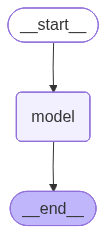

In [7]:
## Simple agent without tools
from langchain.agents import create_agent
from langchain_groq import ChatGroq

llm = ChatGroq(model="qwen/qwen3-32b")
agent = create_agent(
    model=llm,
    tools =[],
    system_prompt = "you are a helpful assistant"
)
agent

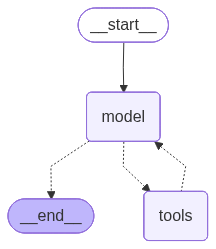

In [8]:
def get_weather(city:str)-> str:
    """Get the weather for a city"""
    return f"The weather in {city} is sunny"


agent = create_agent(
    model='gpt-5',
    tools =[get_weather],
    system_prompt = "you are a helpful assistant"
)
agent

In [10]:
response = agent.invoke({"role": "user",
 "content": "What is the weather in Bangalore?"})
response["messages"]

[AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 181, 'prompt_tokens': 130, 'total_tokens': 311, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 128, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-D3kDztKxNnZAzl4OJWuQ8sMmT1z67', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019c0f68-aa80-7492-a6da-de1295865458-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'Paris'}, 'id': 'call_jzZr6Rkmeo1a9JoDmjXju5mI', 'type': 'tool_call'}, {'name': 'get_weather', 'args': {'city': 'London'}, 'id': 'call_6o5AcWiONr9zVEAZtjJ8UczI', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 130, 'output_tokens': 181, 'total_tokens': 311, 'input_token_detail

In [11]:
agent.invoke({"messages":"What is the weather in Bangalore?"})

{'messages': [HumanMessage(content='What is the weather in Bangalore?', additional_kwargs={}, response_metadata={}, id='f3db75fa-85bc-4789-8756-6eded945296a'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 152, 'prompt_tokens': 141, 'total_tokens': 293, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 128, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-D3kEFJC7uRN2c9nNvFjCr3JjpgasC', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019c0f68-e6c1-74b0-9222-d2b966fdf5ef-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'Bangalore'}, 'id': 'call_YzrdRm8jXtPnf9pBlfAiUwmT', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 141, 'output_to

### Tools
Models can request to call tools that perform tasks such as fetching data from a database, searching the web, or running code. Tools are pairings of:
1. A schema, including the name of the tool, a description, and/or argument definitions (often a JSON schema)
2. A function or coroutine to execute.

In [13]:
import os
from langchain.chat_models import init_chat_model
os.environ['GROQ_API_KEY'] =os.getenv('GROQ_API_KEY')

model = init_chat_model("groq:qwen/qwen3-32b")
response = model.invoke("Why do parrots talk?")
response

AIMessage(content='<think>\nOkay, so I need to figure out why parrots talk. Let\'s start by recalling what I know about parrots. They are birds known for mimicking sounds, including human speech. But why do they do that? Maybe it\'s related to their anatomy or behavior.\n\nFirst, I remember that some birds can mimic sounds, like parrots, mynah birds, and certain types of parakeets. Parrots have a syrinx, which is their vocal organ, located at the base of the trachea. This might be more developed in parrots, allowing them to produce a wider range of sounds. So their ability to mimic might be due to the structure of their syrinx.\n\nAnother angle is social behavior. Parrots are social animals and live in flocks. Mimicking sounds could be a way to communicate with others in the flock. Maybe they use mimicry to bond, play, or establish social hierarchies. In captivity, parrots might mimic humans to communicate with their owners, trying to fit into their new environment.\n\nI also think abo

In [15]:
from langchain.tools import tool

@tool
def get_weather(location:str)->str:
    """Get the waether at a location"""
    return f"It's sunny in '{location}'"

model_with_tools = model.bind_tools([get_weather])

In [18]:
response = model_with_tools.invoke("What is a weather like in Bangalore?")
for tool_call in response.tool_calls:
    ## View tool calls made by the model
    print(f"Tool: {tool_call['name']}")
    print(f"Args: {tool_call['args']}")

Tool: get_weather
Args: {'location': 'Bangalore'}


### Tool Execution Loops

In [19]:
# Step 1: Model generates tool calls
messages = [{"role": "user", "content": "What's the weather in Boston?"}]
ai_msg = model_with_tools.invoke(messages)
messages.append(ai_msg)

# Step 2: Execute tools and collect results
for tool_call in ai_msg.tool_calls:
    # Execute the tool with the generated arguments
    tool_result = get_weather.invoke(tool_call)
    messages.append(tool_result)

# Step 3: Pass results back to model for final response
final_response = model_with_tools.invoke(messages)
print(final_response.text)
# "The current weather in Boston is 72°F and sunny."

The weather in Boston is sunny today. Have a great day! ☀️


In [20]:
messages

[{'role': 'user', 'content': "What's the weather in Boston?"},
 AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user is asking for the weather in Boston. I need to use the get_weather function. Let me check the function parameters. It requires a location, which is Boston here. I'll call the function with location set to Boston. Make sure the JSON is correctly formatted with the name and arguments.\n", 'tool_calls': [{'id': 'n5rshb0hy', 'function': {'arguments': '{"location":"Boston"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 86, 'prompt_tokens': 154, 'total_tokens': 240, 'completion_time': 0.137620315, 'completion_tokens_details': {'reasoning_tokens': 62}, 'prompt_time': 0.006191604, 'prompt_tokens_details': None, 'queue_time': 0.049914764, 'total_time': 0.143811919}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'l